# Newton's Second Law

This version keeps each experiment self-contained: the controls and animation appear together.

It uses ordinary Matplotlib objects only: `Rectangle`, `ax.arrow()`, `ax.text()` and a simple frame loop.

## 1. Motion demo

Change $F$ and $m$. The acceleration is

$$a=\frac{F}{m}$$

Press **Run** to watch the block move.


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display, clear_output
import asyncio


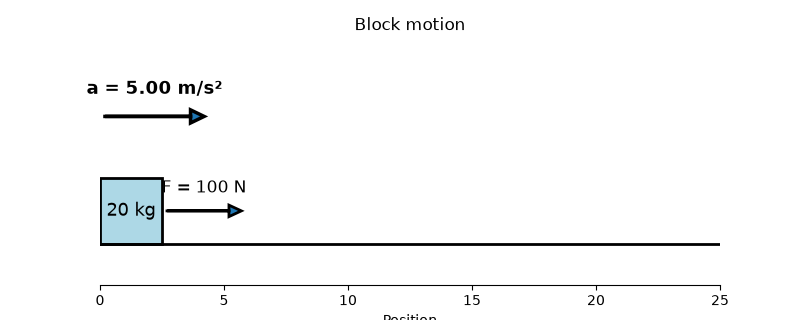

In [48]:
# ============================================================
# DEMO 1: vary F and m, then watch the block move
# Everything for this demo is in this one cell.
# ============================================================

force_slider = widgets.IntSlider(
    value=100, min=20, max=300, step=20,
    description="Force F (N):",
    continuous_update=False
)

mass_slider = widgets.IntSlider(
    value=20, min=5, max=60, step=5,
    description="Mass m (kg):",
    continuous_update=False
)

run_button = widgets.Button(
    description="Run",
    button_style="primary",
    icon="play"
)

reset_button = widgets.Button(description="Reset")
value_label = widgets.HTML()
sim_output = widgets.Output(layout=widgets.Layout(width="700px"))


def draw_demo_frame(x=0.0):
    F = force_slider.value
    m = mass_slider.value
    a = F / m

    value_label.value = (
        f"<b>F = {F} N</b><br>"
        f"<b>m = {m} kg</b><br>"
        f"<b>a = {a:.2f} m/s²</b>"
    )

    with sim_output:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(8, 3.2))
        ax.set_xlim(0, 25)
        ax.set_ylim(0, 6)

        # Ground
        ax.axhline(1, color="black", linewidth=2)

        # Block
        block = Rectangle(
            (x, 1), 2.5, 1.6,
            facecolor="lightblue",
            edgecolor="black",
            linewidth=2
        )
        ax.add_patch(block)
        ax.text(x + 1.25, 1.8, f"{m} kg", ha="center", va="center", fontsize=13)

        # Applied force arrow
        ax.arrow(
            x + 2.7, 1.8, 3.0, 0,
            head_width=0.28,
            head_length=0.5,
            length_includes_head=True,
            linewidth=2
        )
        ax.text(x + 4.2, 2.25, f"F = {F} N", ha="center", fontsize=12)

        # Acceleration arrow
        ax.arrow(
            x + 0.2, 4.1, 4.0, 0,
            head_width=0.32,
            head_length=0.55,
            length_includes_head=True,
            linewidth=2.5
        )
        ax.text(
            x + 2.2, 4.65,
            f"a = {a:.2f} m/s²",
            ha="center", fontsize=13, fontweight="bold"
        )

        ax.set_title("Block motion")
        ax.set_xlabel("Position")
        ax.set_yticks([])
        ax.spines[['left', 'right', 'top']].set_visible(False)
        plt.show()
        plt.close(fig)


async def run_demo_animation():
    F = force_slider.value
    m = mass_slider.value
    a = F / m

    run_button.disabled = True
    force_slider.disabled = True
    mass_slider.disabled = True

    # Keep the animation inside the visible 0–25 m window.
    times = np.linspace(0, 2.0, 35)
    for t in times:
        x = min(21.5, 0.5 * a * t**2)
        draw_demo_frame(x)
        await asyncio.sleep(0.05)

    run_button.disabled = False
    force_slider.disabled = False
    mass_slider.disabled = False


def run_clicked(button):
    asyncio.create_task(run_demo_animation())


def reset_clicked(button):
    draw_demo_frame(0.0)


def controls_changed(change=None):
    draw_demo_frame(0.0)


run_button.on_click(run_clicked)
reset_button.on_click(reset_clicked)
force_slider.observe(controls_changed, names="value")
mass_slider.observe(controls_changed, names="value")

controls = widgets.VBox([
    widgets.HTML("<h3>Controls</h3>"),
    force_slider,
    mass_slider,
    widgets.HBox([run_button, reset_button]),
    value_label
], layout=widgets.Layout(width="320px"))

# Controls and simulation are deliberately displayed together.
display(widgets.HBox([
    controls,
    sim_output
], layout=widgets.Layout(align_items="flex-start", gap="18px")))

# Show the box immediately, before Run is pressed.
draw_demo_frame(0.0)


## 2. Build an $F$ versus $a$ graph

For this experiment the mass is fixed.

Change only $F$, press **Run + record**, and collect the pair $(a,F)$.

Because

$$F=ma$$

a plot of $F$ against $a$ should be a straight line. Its slope is the mass.


In [49]:
# ============================================================
# DEMO 2: fixed mass, vary F, record (a, F) pairs
# Everything for this experiment is in this one cell.
# ============================================================

MASS = 20  # kg -- students can change this one number

force_exp = widgets.IntSlider(
    value=40, min=20, max=300, step=20,
    description="Force F (N):",
    continuous_update=False
)

run_record = widgets.Button(
    description="Run + record",
    button_style="primary",
    icon="play"
)

reset_exp = widgets.Button(description="Reset block")
clear_data = widgets.Button(description="Clear data")
exp_value_label = widgets.HTML()

exp_output = widgets.Output(layout=widgets.Layout(width="700px"))
graph_output = widgets.Output(layout=widgets.Layout(width="760px"))

F_values = []
a_values = []


def draw_experiment_frame(x=0.0):
    F = force_exp.value
    a = F / MASS

    exp_value_label.value = (
        f"<b>Fixed mass = {MASS} kg</b><br>"
        f"<b>F = {F} N</b><br>"
        f"<b>a = {a:.2f} m/s²</b>"
    )

    with exp_output:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(8, 3.2))
        ax.set_xlim(0, 25)
        ax.set_ylim(0, 6)
        ax.axhline(1, color="black", linewidth=2)

        block = Rectangle(
            (x, 1), 2.5, 1.6,
            facecolor="lightblue",
            edgecolor="black",
            linewidth=2
        )
        ax.add_patch(block)
        ax.text(x + 1.25, 1.8, f"{MASS} kg", ha="center", va="center", fontsize=13)

        ax.arrow(
            x + 2.7, 1.8, 3.0, 0,
            head_width=0.28,
            head_length=0.5,
            length_includes_head=True,
            linewidth=2
        )
        ax.text(x + 4.2, 2.25, f"F = {F} N", ha="center", fontsize=12)

        ax.arrow(
            x + 0.2, 4.1, 4.0, 0,
            head_width=0.32,
            head_length=0.55,
            length_includes_head=True,
            linewidth=2.5
        )
        ax.text(
            x + 2.2, 4.65,
            f"a = {a:.2f} m/s²",
            ha="center", fontsize=13, fontweight="bold"
        )

        ax.set_title("Fixed-mass experiment")
        ax.set_xlabel("Position")
        ax.set_yticks([])
        ax.spines[['left', 'right', 'top']].set_visible(False)
        plt.show()
        plt.close(fig)


def draw_F_a_graph():
    with graph_output:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.scatter(a_values, F_values, s=70)

        if len(a_values) >= 2:
            slope, intercept = np.polyfit(a_values, F_values, 1)
            xmax = max(a_values) * 1.12
            xx = np.linspace(0, xmax, 100)
            ax.plot(xx, slope * xx + intercept)
            ax.text(
                0.05, 0.92,
                f"slope = {slope:.1f} kg",
                transform=ax.transAxes,
                fontsize=12
            )

        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("Acceleration, a (m/s²)")
        ax.set_ylabel("Force, F (N)")
        ax.set_title("F versus a")
        ax.grid(alpha=0.3)
        plt.show()
        plt.close(fig)


async def run_and_record():
    F = force_exp.value
    a = F / MASS

    run_record.disabled = True
    force_exp.disabled = True

    times = np.linspace(0, 2.0, 35)
    for t in times:
        x = min(21.5, 0.5 * a * t**2)
        draw_experiment_frame(x)
        await asyncio.sleep(0.05)

    # Record exactly one pair at the end of the run.
    a_values.append(a)
    F_values.append(F)
    draw_F_a_graph()

    run_record.disabled = False
    force_exp.disabled = False


def run_record_clicked(button):
    asyncio.create_task(run_and_record())


def reset_exp_clicked(button):
    draw_experiment_frame(0.0)


def clear_data_clicked(button):
    F_values.clear()
    a_values.clear()
    draw_F_a_graph()


def force_exp_changed(change=None):
    draw_experiment_frame(0.0)


run_record.on_click(run_record_clicked)
reset_exp.on_click(reset_exp_clicked)
clear_data.on_click(clear_data_clicked)
force_exp.observe(force_exp_changed, names="value")

exp_controls = widgets.VBox([
    widgets.HTML("<h3>Controls</h3>"),
    force_exp,
    widgets.HBox([run_record, reset_exp]),
    clear_data,
    exp_value_label
], layout=widgets.Layout(width="320px"))

# Controls + simulation are one unit.
display(widgets.HBox([
    exp_controls,
    exp_output
], layout=widgets.Layout(align_items="flex-start", gap="18px")))

# Graph directly underneath the experiment.
display(graph_output)

# Show both outputs immediately.
draw_experiment_frame(0.0)
draw_F_a_graph()


Output(layout=Layout(width='760px'))